### Integrantes:
    - Harold Vargas 
    - David Lopez

# 1. Comprensión del negocio

## Problema a resolver 


La aseguradora recibe cada día muchísimas solicitudes por choques de autos. Algunas de estas peticiones son falsas, o sea, buscan sacar dinero que no les corresponde. Encontrar estos engaños a tiempo ayuda a prevenir pérdidas de dinero, baja las cuotas para los clientes sinceros y conserva la fe en todo el sistema de seguros. Este analisís busca crear un sistema que prediga si un reclamo es falso (fraud_reported = “Y”) o no (fraud_reported = “N”), usando datos antiguos con detalles sobre quién está asegurado, el coche, la póliza y cómo pasó el suceso.

## Objetivo de la empresa 


La meta primordial de la compañía de seguros consiste en aumentar al máximo la identificación de engaños verdaderos, reduciendo al mismo tiempo aquellos que se escapan a la vista. Puesto que el no descubrir un fraude (un error de tipo negativo) implica un gasto enorme (dinero entregado incorrectamente, desperdicio de medios), la entidad da preferencia a atrapar cuantas más solicitudes fraudulentas sea factible, aun cuando esto suponga examinar a mano ciertas situaciones que después se demuestren como válidas (errores de tipo positivo). A pesar de lo anterior, es igualmente crucial gestionar los errores positivos para evitar sobrecargar al grupo de análisis con asuntos que no requieran ser examinados.

## Criterios de exito 


La forma en que mediremos qué tan bien funcionan los modelos se basará en estos indicadores, ordenados por importancia:

- **Recuperación de la categoría de fraude:** Es el indicador principal. Indica qué parte de los fraudes verdaderos el modelo logra captar bien. Una recuperación alta quiere decir que casi ningún fraude se nos escapa.

- **Puntuación F1 de la categoría de fraude:** Busca un balance entre qué tan acertado es el modelo y cuántos casos atrapa. Esto importa mucho si tenemos mucha más información de una clase que de la otra.

- **Exactitud de la categoría de fraude:** Sirve para limitar el número de alertas falsas. Queremos que, de lo que el modelo marca como fraude, una gran parte sea fraude de verdad.

- **ROC-AUC:** Es una medida adicional que ve qué tan bien puede el modelo distinguir entre las dos categorías en general.

- **Precisión general:** Solo como dato de referencia, pues puede ser confusa si hay mucha disparidad entre las clases.

Como la información disponible es limitada, tendremos mucho cuidado en la forma de trabajar (usando validación cruzada, separando los datos de forma equilibrada, escogiendo bien las características) para no adaptarnos demasiado a esos datos y asegurar que las mediciones muestren el poder predictivo real del modelo.

## Implicaciones de los errores de clasificación 

Un falso negativo significa que una situación fraudulenta pasa sin ser vista. La compañía de seguros termina abonando una cuenta que no debería, causando una merma directa. Este es el fallo que sale más caro.

Un falso positivo quiere decir que un caso real se señala erróneamente como fraude. Esto provoca gastos de funcionamiento al tener que revisar algo que no era necesario y puede molestar al cliente, pero no resulta en un desembolso injustificado.

Al escoger el modelo definitivo, se dará preferencia a reducir al máximo los falsos negativos, siempre y cuando los falsos positivos se mantengan en un nivel admisible.

# 2. Comprensión de los datos

## Diccionario 

| Variable | Descripción | Tipo real |
|----------|------------|-----------|
| months_as_customer | Tiempo que el asegurado ha sido cliente (en meses) | Numérico (int64) |
| age | Edad del asegurado | Numérico (int64) |
| policy_number | Número único de la póliza | Numérico (int64)|
| policy_bind_date | Fecha en que se inició la póliza | Categórico (object)|
| policy_state | Estado donde se emitió la póliza | Categórico (object) |
| policy_csl | Límite de cobertura (CSL) | Categórico (object) |
| policy_deductable | Monto deducible de la póliza | Numérico (int64) |
| policy_annual_premium | Prima anual pagada | Numérico (float64) |
| umbrella_limit | Límite del seguro paraguas | Numérico (int64) |
| insured_zip | Código postal de la persona | Numérico (int64) |
| insured_sex | Sexo de la peersona | Categórico (object) |
| insured_education_level | Nivel educativo de la persona  | Categórico (object) |
| insured_occupation | Ocupación de la persona| Categórico (object) |
| insured_hobbies | Pasatiempos de la persona| Categórico (object) |
| insured_relationship | Relación de la persona con el titular | Categórico (object) |
| capital-gains | Ganancias de capital | Numérico (float64) |
| capital-loss | Pérdidas de capital | Numérico (float64) |
| incident_date | Fecha del incidente reportado | Categórico (object)|
| incident_type | Tipo de incidente | Categórico (object) |
| collision_type | Tipo de colisión | Categórico (object) |
| incident_severity | Severidad del incidente | Categórico (object) |
| authorities_contacted | Autoridad contactada | Categórico (object) |
| incident_state | Estado donde ocurrió el incidente | Categórico (object) |
| incident_city | Ciudad donde ocurrió el incidente | Categórico (object) |
| incident_location | Ubicación adicional | Categórico (object) |
| incident_hour_of_the_day | Hora del incidente (0–23) | Numérico (int64) |
| number_of_vehicles_involved | Número de vehículos involucrados | Numérico (int64) |
| property_damage | ¿Hubo daño a propiedad? | Categórico (object) |
| bodily_injuries | Número de lesionados | Numérico (int64) |
| witnesses | Número de testigos | Numérico (int64) |
| police_report_available | ¿Se tiene reporte policial? | Categórico (object) |
| total_claim_amount | Monto total reclamado | Numérico (float64) |
| injury_claim | Monto reclamado por lesiones | Numérico (float64) |
| property_claim | Monto reclamado por daños a propiedad | Numérico (float64) |
| vehicle_claim | Monto reclamado por daños al vehículo | Numérico (float64) |
| auto_make | Marca del vehículo | Categórico (object) |
| auto_model | Modelo del vehículo | Categórico (object) |
| auto_year | Año del vehículo | Numérico (int64) |
| fraud_reported | Variable objetivo: ¿se reportó fraude? | Categórico (object) – valores "Y"/"N" |

## Lectura de datos 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew


In [3]:
df = pd.read_csv('insurance_claims.csv')

print("Shape del dataset:", df.shape)
print("\nPrimeras 5 filas:")
df.head()

Shape del dataset: (1000, 40)

Primeras 5 filas:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [5]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [6]:
# Verificación de valores nulos
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

Al revisar qué tan buenos son los datos, notamos que la inmensa mayoría de las columnas no tienen huecos de información, lo cual es bueno para hacer el estudio. No obstante, encontramos dos apartados sin ningún dato: _c39 y authorities_contacted. La columna _c39 está completamente vacía, con sus 1000 entradas como nulas, lo que sugiere que es una columna inútil, posiblemente creada por un fallo al guardar el archivo CSV (quizás una fila vacía o un número repetido). Como no da ningún aporte útil, toca quitarla en la parte de alistar los datos.

En cuanto a la columna authorities_contacted, le faltan 91 registros, que vienen siendo casi el 9. 1% del total. Esta columna dice qué ente se llamó después del suceso (policía, paramédicos, etc. ). Que falte este dato puede ser porque se olvidaron de anotarlo o porque en verdad no se llamó a nadie, pero esa posibilidad no se marcó claramente. Como este campo podría ser clave para ver si hay engaño (por ejemplo, no llamar a la policía podría ligarse a trampas), no es buena idea borrar las filas sin dato, pues así se haría más pequeña la muestra ya limitada. Mejor, al preparar, se elegirá un método apropiado para rellenar, como poner lo más común, crear una opción que diga “no se sabe” o ver si ya existe una marca para “ninguna entidad”.

Las otras columnas no tienen faltantes, lo que hace más fácil limpiar y nos deja usar todos los registros para crear el modelo.

In [8]:
print("Tipos de variables por columna:\n")
print(df.dtypes)

Tipos de variables por columna:

months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location              

In [9]:
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numeric_vars)}):\n{numeric_vars}\n")
print(f"Variables categóricas ({len(categorical_vars)}):\n{categorical_vars}")

Variables numéricas (19):
['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', '_c39']

Variables categóricas (21):
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

exclude_outlier = ['policy_number', 'insured_zip', 'auto_year', '_c39']
numeric_for_outlier = [col for col in numeric_cols if col not in exclude_outlier]

print("Variables numéricas analizadas para outliers:", numeric_for_outlier)

Variables numéricas analizadas para outliers: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']


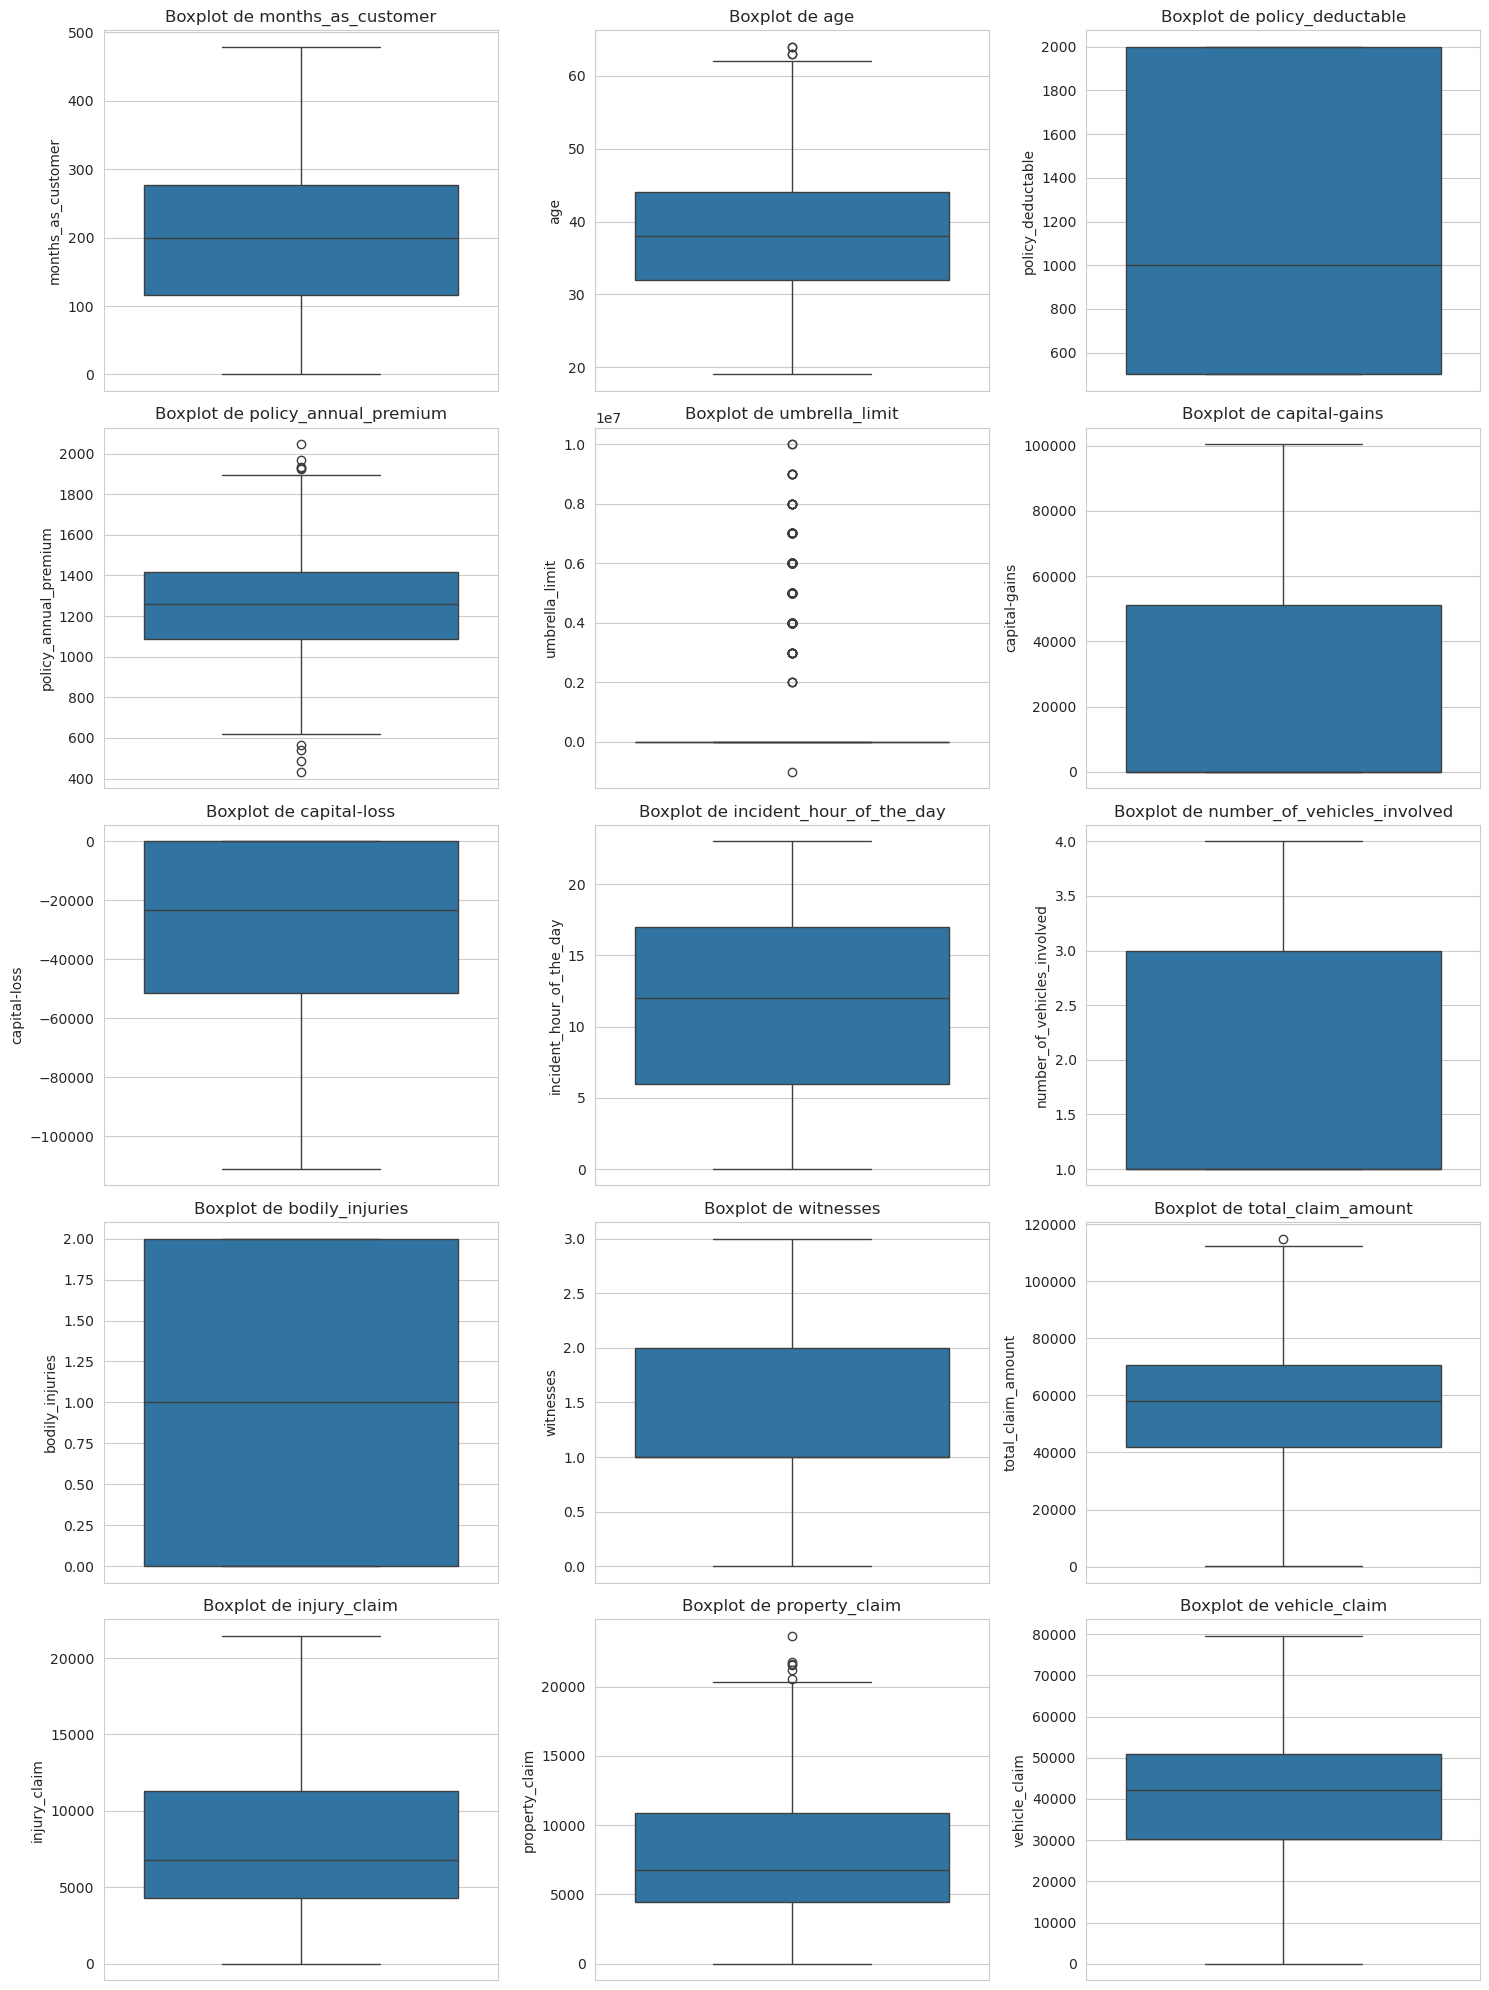

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_for_outlier):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    
for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [ ]:
df[numeric_for_outlier].describe()

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,1136.000000,1256.406150,1.101000e+06,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000
std,115.113174,9.140287,611.864673,244.167395,2.297407e+06,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893
min,0.000000,19.000000,500.000000,433.330000,-1.000000e+06,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000
25%,115.750000,32.000000,500.000000,1089.607500,0.000000e+00,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000
50%,199.500000,38.000000,1000.000000,1257.200000,0.000000e+00,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000
75%,276.250000,44.000000,2000.000000,1415.695000,0.000000e+00,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000
max,479.000000,64.000000,2000.000000,2047.590000,1.000000e+07,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000


Al revisar los números básicos, notamos que las variables con valores numéricos se comportan de manera distinta. Para empezar, la antigüedad del cliente, months_as_customer, tiene una variación grande, yendo de cero hasta 479 meses; el promedio es de 204 meses (unos 17 años) y la desviación es de 115, señalando que hay bastante diferencia en cuánto tiempo llevan siendo clientes. La variable age muestra un patrón que tiene sentido para personas aseguradas adultas, con edades entre 19 y 64 años, un promedio de 39 y una desviación pequeña de 9 años, lo que implica que la mayoría se agrupa en edades medias. Sobre los datos económicos de la póliza, policy_deductable suele tomar valores de 500, 1000 y 2000 dólares, con un promedio de 1136 dólares; por otro lado, policy_annual_premium tiene un promedio de 1256 dólares y sus montos van desde 433 hasta 2047 dólares, lo que muestra un esparcimiento moderado. Un punto que llama la atención es umbrella_limit, cuyo valor mínimo es menos un millón y el 75% de los casos llega hasta cero, pero el promedio es 1,101,000. Esta forma de distribuirse sugiere que la mayor parte de los clientes no tiene seguro adicional (cero), pero unos cuantos sí tienen límites muy altos (hasta diez millones), creando un desequilibrio fuerte.

En el tema de las cifras de dinero personales, las ganancias de capital tienen un promedio de 25,126 dólares, pero como el 75% de los casos están en cero, esto nos dice que solo un pequeño grupo declara tener ganancias de capital positivas, alcanzando hasta 100,500 dólares como máximo. De forma parecida, las pérdidas de capital promedian unos -26,794 dólares, con el 75% de los valores en cero o bajo cero, y el valor más bajo es de -111,100 dólares, lo cual indica que las pérdidas se concentran en ciertos asegurados.

Sobre los datos ligados al suceso, la hora del día del incidente muestra una repartición bastante pareja a lo largo de las 24 horas, con un promedio de 11. 6 (cerca del mediodía). Los datos sobre cuántos carros estuvieron involucrados, los heridos y los testigos tienen cifras pequeñas (entre 1 y 4 carros, de 0 a 2 lesionados, y de 0 a 3 testigos cada uno), con promedios cercanos a 1. 8, 1. 0 y 1. 5 respectivamente, lo cual apunta a que los sucesos suelen ser poco complicados. Por último, las cantidades pedidas muestran mucha diferencia: el monto total reclamado promedia 52,762 dólares, oscilando entre 100 y 114,920 dólares, mientras que sus partes (reclamación por lesiones, por daños a la propiedad y por el vehículo) tienen repartos desiguales, siendo la reclamación por el carro el mayor rubro con un promedio de 37,929 dólares, seguido por la de lesiones con 7,433 dólares y la de propiedad con 7,400 dólares. Este patrón sugiere que, en general, arreglar el vehículo es lo que más influye en el total solicitado.

In [13]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_summary = {}
for col in numeric_for_outlier:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    outlier_summary[col] = {
        'n_outliers': len(outliers),
        'pct_outliers': (len(outliers) / len(df)) * 100,
        'lower_bound': lb,
        'upper_bound': ub
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                             n_outliers  pct_outliers   lower_bound  \
months_as_customer                  0.0           0.0    -125.00000   
age                                 4.0           0.4      14.00000   
policy_deductable                   0.0           0.0   -1750.00000   
policy_annual_premium               9.0           0.9     600.47625   
umbrella_limit                    202.0          20.2       0.00000   
capital-gains                       0.0           0.0  -76537.50000   
capital-loss                        0.0           0.0 -128750.00000   
incident_hour_of_the_day            0.0           0.0     -10.50000   
number_of_vehicles_involved         0.0           0.0      -2.00000   
bodily_injuries                     0.0           0.0      -3.00000   
witnesses                           0.0           0.0      -0.50000   
total_claim_amount                  1.0           0.1   -1357.50000   
injury_claim                        0.0           0.0   -6220.00000   
proper

Al revisar con el método del rango intercuartil, vimos que varias columnas con números tienen valores raros, pero la cantidad varía, por lo que merecen tratarse de forma distinta. La columna months_as_customer muestra un valor extremo arriba (517 meses), pero es solo un caso, así que no es gran cosa. age tiene 4 valores fuera de lo común (0. 4% del total) en el lado alto (62 años), los cuales son posibles para clientes mayores. policy_annual_premium posee 9 valores atípicos (0. 9%) arriba (1,905 dólares), lo que indica pólizas muy caras, pero podrían ser por carros de lujo o seguros especiales.

Un hallazgo más notable es umbrella_limit, con 202 valores raros (20. 2% de todos los datos). Esto se debe a que la mayoría son 0, mientras que unos pocos tienen coberturas enormes (millones de dólares). Como esta columna refleja si la gente contrata o no ese seguro extra, estos números no son fallos, sino una forma normal de cómo se distribuyen y probablemente necesiten un manejo o cambio especial al hacer el modelo.

En capital-gains no salieron valores atípicos con el IQR, pero su forma tan inclinada (75% en 0) sugiere que los números positivos en el resto son parte normal de esa columna. capital-loss, en cambio, tiene números muy bajos que son esperables para pérdidas de capital. Las columnas sobre accidentes (incident_hour_of_the_day, number_of_vehicles_involved, bodily_injuries, witnesses) tienen pocos o ningún valor raro, lo que habla de datos consistentes.

Para terminar, las columnas de cuánto se reclama tienen algunos valores extremos: total_claim_amount tiene 1 valor fuera (0. 1%) arriba, property_claim tiene 6 (0. 6%), y injury_claim y vehicle_claim no muestran valores atípicos según este método. Que haya pocos valores extremos en los montos dice que las reclamaciones gigantes son raras, lo cual tiene sentido en seguros de autos. En resumen, el análisis muestra que la mayoría de los valores raros no son errores claros, sino extremos reales que habrá que ver en la limpieza para decidir si se cambian, se dejan o se ajustan, sobre todo porque la base de datos es pequeña.

In [7]:
print("Distribución de fraud_reported:")
print(df['fraud_reported'].value_counts())
print("\nProporciones:")
print(df['fraud_reported'].value_counts(normalize=True))

Distribución de fraud_reported:
fraud_reported
N    753
Y    247
Name: count, dtype: int64

Proporciones:
fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64


El dato fraud_reported, el cual nos dice si una solicitud fue marcada como engañosa, muestra un equilibrio algo desigual entre sus grupos. De las 1000 entradas en total, 753 son solicitudes que no son fraude (un 75. 3 por ciento) y 247 sí lo son (un 24. 7 por ciento). Esto quiere decir que alrededor de una de cada cuatro solicitudes es fraudulenta, lo cual es bastante significativo y justifica que necesitemos herramientas de predicción bien hechas. No obstante, este desequilibrio significa que un programa simple que siempre diga “no hay fraude” lograría una precisión general del 75. 3 por ciento, lo que podría hacer creer que funciona bien sin realmente encontrar las instancias de fraude. Por ello, siguiendo lo acordado en los objetivos, las formas clave de medir el rendimiento de los programas serán el recall para la categoría de fraude y el F1-score, porque estas penalizan los errores donde no se detecta el fraude y balancean la exactitud. Además, como solo tenemos 1000 datos, hay que ser muy cuidadosos al separar la información (como usar estratificación para asegurar que la proporción de fraude sea igual en los conjuntos de entrenamiento y prueba) y al validar el programa para no sobreajustar. Este desbalance también podría pedirnos aplicar métodos como el sobremuestreo (usando SMOTE) o modificar los pesos de las categorías al crear el modelo para mejorar la habilidad de identificar el fraude sin perder demasiada exactitud.

# 3. Preparación de los datos

## Elminación de columnas no necesarias 


In [14]:
columns_to_drop = ['_c39', 'policy_number', 'auto_model', 'incident_location']

df_clean = df.drop(columns=columns_to_drop)

print("Columnas originales:", df.shape[1])
print("Columnas después de eliminación:", df_clean.shape[1])
print("\nColumnas restantes:")
print(df_clean.columns.tolist())

Columnas originales: 40
Columnas después de eliminación: 36

Columnas restantes:
['months_as_customer', 'age', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_year', 'fraud_reported']


## Manejo de valores nulos 

In [15]:
print("Categorías únicas en authorities_contacted:")
print(df_clean['authorities_contacted'].unique())

Categorías únicas en authorities_contacted:
['Police' nan 'Fire' 'Other' 'Ambulance']


In [16]:
print("\nFrecuencia de cada valor (incluyendo nulos):")
print(df_clean['authorities_contacted'].value_counts(dropna=False))


Frecuencia de cada valor (incluyendo nulos):
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64


In [17]:
print("\nPorcentaje de cada valor:")
print(df_clean['authorities_contacted'].value_counts(dropna=False, normalize=True) * 100)


Porcentaje de cada valor:
authorities_contacted
Police       29.2
Fire         22.3
Other        19.8
Ambulance    19.6
NaN           9.1
Name: proportion, dtype: float64


In [18]:
print("\nMuestra de registros con authorities_contacted nulo:")
df_clean[df_clean['authorities_contacted'].isnull()].head()


Muestra de registros con authorities_contacted nulo:


,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_year,fraud_reported
4,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,...,0,1,NO,6500,1300,650,4550,Accura,2009,N
13,121,34,2012-10-26,OH,100/300,1000,936.61,0,464652,FEMALE,...,1,1,NO,7280,1120,1120,5040,Toyota,2010,N
27,202,34,2002-07-18,IN,100/300,500,848.07,3000000,607730,MALE,...,2,1,?,5720,1040,520,4160,Suburu,2003,Y
37,289,49,1993-02-03,IL,500/1000,2000,1222.48,0,620757,FEMALE,...,1,1,YES,5330,1230,820,3280,Suburu,2001,N
51,91,27,1994-08-20,IL,100/300,2000,1073.83,0,609930,FEMALE,...,1,2,?,7260,1320,660,5280,BMW,2008,N


In [25]:
df_clean['authorities_contacted'] = df_clean['authorities_contacted'].replace('None', 'Ninguna')

print("Valores únicos después del reemplazo:")
print(df_clean['authorities_contacted'].unique())

print("\nValores nulos después del reemplazo:", df_clean['authorities_contacted'].isnull().sum())

print("\nDistribución actualizada:")
print(df_clean['authorities_contacted'].value_counts())

Valores únicos después del reemplazo:
['Police' 'Ninguna' 'Fire' 'Other' 'Ambulance']

Valores nulos después del reemplazo: 0

Distribución actualizada:
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Ninguna       91
Name: count, dtype: int64


## Tranformación de variables 

In [27]:
print("Tipo de dato actual:")
print("policy_bind_date:", df['policy_bind_date'].dtype)
print("incident_date:", df['incident_date'].dtype)

Tipo de dato actual:
policy_bind_date: object
incident_date: object


In [28]:
print("\nPrimeras 10 filas de policy_bind_date e incident_date:")
df[['policy_bind_date', 'incident_date']].head(10)


Primeras 10 filas de policy_bind_date e incident_date:


,policy_bind_date,incident_date
0,2014-10-17,2015-01-25
1,2006-06-27,2015-01-21
2,2000-09-06,2015-02-22
3,1990-05-25,2015-01-10
4,2014-06-06,2015-02-17
5,2006-10-12,2015-01-02
6,2000-06-04,2015-01-13
7,1990-02-03,2015-02-27
8,1997-02-05,2015-01-30
9,2011-07-25,2015-01-05


In [29]:
df_clean['policy_bind_date'] = pd.to_datetime(df_clean['policy_bind_date'])
df_clean['incident_date'] = pd.to_datetime(df_clean['incident_date'])

In [30]:
print("Tipos de dato después de conversión:")
print(df_clean[['policy_bind_date', 'incident_date']].dtypes)

Tipos de dato después de conversión:
policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object


In [31]:
print("\nPrimeras 5 filas después de conversión:")
df_clean[['policy_bind_date', 'incident_date']].head()


Primeras 5 filas después de conversión:


,policy_bind_date,incident_date
0,2014-10-17,2015-01-25
1,2006-06-27,2015-01-21
2,2000-09-06,2015-02-22
3,1990-05-25,2015-01-10
4,2014-06-06,2015-02-17


In [32]:
print("\nValores nulos en policy_bind_date:", df_clean['policy_bind_date'].isnull().sum())
print("Valores nulos en incident_date:", df_clean['incident_date'].isnull().sum())


Valores nulos en policy_bind_date: 0
Valores nulos en incident_date: 0


### Variables Categoricas 

In [33]:
skewed_vars = ['umbrella_limit', 'capital-gains', 'capital-loss']

print("Estadísticas descriptivas:")
print(df_clean[skewed_vars].describe())

Estadísticas descriptivas:
       umbrella_limit  capital-gains   capital-loss
count    1.000000e+03    1000.000000    1000.000000
mean     1.101000e+06   25126.100000  -26793.700000
std      2.297407e+06   27872.187708   28104.096686
min     -1.000000e+06       0.000000 -111100.000000
25%      0.000000e+00       0.000000  -51500.000000
50%      0.000000e+00       0.000000  -23250.000000
75%      0.000000e+00   51025.000000       0.000000
max      1.000000e+07  100500.000000       0.000000


In [35]:

skewness = df_clean[skewed_vars].apply(lambda x: skew(x.dropna()))
print("\nCoeficiente de asimetría (skewness):")
print(skewness)


Coeficiente de asimetría (skewness):
umbrella_limit    1.804001
capital-gains     0.478132
capital-loss     -0.390884
dtype: float64


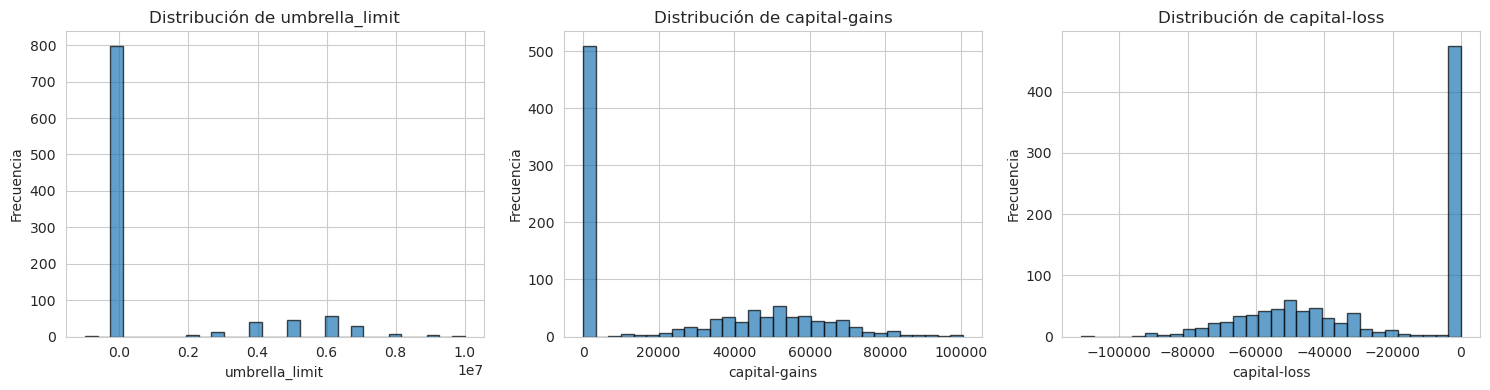

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(skewed_vars):
    axes[i].hist(df_clean[var], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

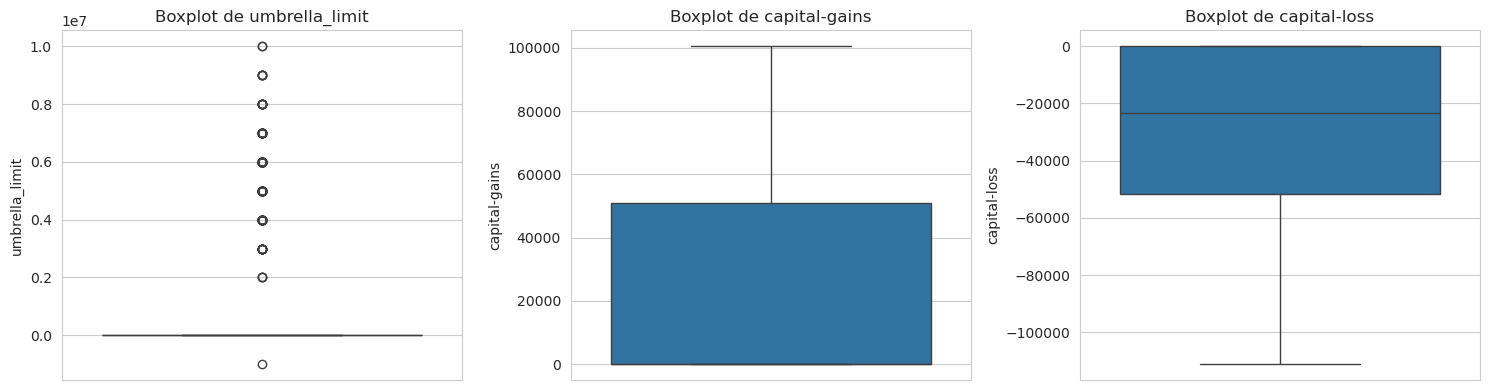

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(skewed_vars):
    sns.boxplot(y=df_clean[var], ax=axes[i])
    axes[i].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

In [38]:
print("\nValores únicos de umbrella_limit (top 10):")
print(df_clean['umbrella_limit'].value_counts().head(10))


Valores únicos de umbrella_limit (top 10):
umbrella_limit
0           798
6000000      57
5000000      46
4000000      39
7000000      29
3000000      12
8000000       8
9000000       5
2000000       3
10000000      2
Name: count, dtype: int64


In [39]:
print("\nResumen detallado de capital-gains:")
print(df_clean['capital-gains'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

print("\nResumen detallado de capital-loss:")
print(df_clean['capital-loss'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))


Resumen detallado de capital-gains:
count      1000.000000
mean      25126.100000
std       27872.187708
min           0.000000
10%           0.000000
25%           0.000000
50%           0.000000
75%       51025.000000
90%       64420.000000
95%       70615.000000
99%       83603.000000
max      100500.000000
Name: capital-gains, dtype: float64

Resumen detallado de capital-loss:
count      1000.000000
mean     -26793.700000
std       28104.096686
min     -111100.000000
10%      -65510.000000
25%      -51500.000000
50%      -23250.000000
75%           0.000000
90%           0.000000
95%           0.000000
99%           0.000000
max           0.000000
Name: capital-loss, dtype: float64


In [40]:
df_clean['umbrella_has'] = (df_clean['umbrella_limit'] > 0).astype(int)

print("Distribución de umbrella_has:")
print(df_clean['umbrella_has'].value_counts())

Distribución de umbrella_has:
umbrella_has
0    799
1    201
Name: count, dtype: int64


In [41]:
df_clean = df_clean.drop(columns=['umbrella_limit'])

print("\nColumnas después de eliminar umbrella_limit:")
print(df_clean.columns.tolist())


Columnas después de eliminar umbrella_limit:
['months_as_customer', 'age', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_year', 'fraud_reported', 'umbrella_has']


La columna umbrella_limit mostraba un reparto muy desigual: casi el 80% de las entradas tenían cero, mientras que las demás llegaban a cifras enormes (de 2 a 10 millones). Este panorama creaba una fuerte inclinación (con un coeficiente de 1. 80) y podía hacer que los casos más altos influyeran demasiado en el modelo, sobre todo en la regresión logística, aun cuando la mayoría de las pólizas no tienen esa protección adicional. Desde el punto de vista práctico, lo importante no es la cifra exacta del tope, sino si la persona tiene o no ese seguro extra. Así pues, transformar umbrella_limit en un simple sí o no (umbrella_has: 1 si sí tiene, 0 si no) permite captar el impacto que buscamos de forma más firme, simplifica el modelo y previene posibles fallos por exceso de adaptación, algo crucial por tener pocos datos.

### Variables Numericas 

In [42]:
categorical_vars = [col for col in df_clean.select_dtypes(include=['object']).columns 
                    if col != 'fraud_reported']
print("Variables categóricas a procesar:")
print(categorical_vars)
print(f"\nTotal: {len(categorical_vars)} variables")

Variables categóricas a procesar:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make']

Total: 16 variables


In [43]:
for col in categorical_vars:
    n_unique = df_clean[col].nunique()
    print(f"{col}: {n_unique} categorías únicas")

policy_state: 3 categorías únicas
policy_csl: 3 categorías únicas
insured_sex: 2 categorías únicas
insured_education_level: 7 categorías únicas
insured_occupation: 14 categorías únicas
insured_hobbies: 20 categorías únicas
insured_relationship: 6 categorías únicas
incident_type: 4 categorías únicas
collision_type: 4 categorías únicas
incident_severity: 4 categorías únicas
authorities_contacted: 5 categorías únicas
incident_state: 7 categorías únicas
incident_city: 7 categorías únicas
property_damage: 3 categorías únicas
police_report_available: 3 categorías únicas
auto_make: 14 categorías únicas


# 4. Modelado

# 5. Evaluación

# 6. Despliegue